<a href="https://colab.research.google.com/github/IVANDERHANSON/Disaster-Classification/blob/main/Disaster_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Visualization

In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

df_fire = pd.read_csv('/content/fire.csv')
print('Fire Data:')
display(df_fire.head())

df_flood = pd.read_csv('/content/flood.csv')
print('\nFlood Data:')
display(df_flood.head())

df_earthquake = pd.read_csv('/content/earthquake.csv')
print('\nEarthquake Data:')
display(df_earthquake.head())

Fire Data:


,created_at,id_str,full_text
0,2018-01-01 11:41:55+00:00,947795014595231744,kebakaran di panji mas rangkas bitung pbrik kayu
1,2018-01-01 12:35:18+00:00,947808448128749568,telah terjadi kebakaran di rs solihatin bagian belakang rumah sakit tepatnya di dekat kamar mayat beberapa mayat melarikan diri terbrit birit karena kepanasan wakakakakakak
2,2018-01-01 14:51:53+00:00,947842824120045569,pukul 2152 terjadi kebakaran di lantai 5 gd moratelindo menteng jakarta pusat saat ini sudah dapat dipadamkan oleh 15 unit dpk dan selanjutnya dilakukan operasi ventilasi ()
3,2018-01-01 14:53:58+00:00,947843346524807168,menyerahkan bantuan family kit kepada korban kebakaran di jalan poncol jaya rt 12/05 kuningan barat jakarta selatan
4,2018-01-01 15:01:10+00:00,947845158208282625,kebakaran di palu hanguskan empat rumah



Flood Data:


,created_at,id_str,full_text
0,2018-01-01 04:01:44+00:00,947679206288195584,semoga mangsa-mangsa banjir tabah di atas ujian yang menimpa
1,2018-01-01 04:15:05+00:00,947682565606973441,13 janji akan mencari solusi banjir jakarta dan kemacetan jakarta ketika jadi presiden bahkan statemen di 2014 akan menggunakan cara lain namun faktanya kini banyak barisan pendukung yang menyalahkan anies sandi dengan fakta jakarta masih banjir dan macet ingat janji ini
2,2018-01-02 04:24:48+00:00,948047400697937920,ingin tenangkan diri di musim banjir? -memancing -sukat air -bakar ikan -berehat di atas rumah rakit khas musim cuti rm20 seorang (termasukhomestay) p/s ikan dibekalkan minimum 8 orang
3,2018-01-02 09:30:16+00:00,948124273683632128,intensitas dan curah hujan yang tinggi telah menyebabkan banjir di berbagai daerah di tanah air kala banjir melanda tetap tenang dan tingkatkan kewaspadaan berikut beberapa poin yang dapat dilakukan guna mengurangi risiko banjir
4,2018-01-02 16:25:19+00:00,948228723706228736,ayuh kita bersama menjayakan misi bantuan mangsa banjir di mersing pada 3 jangan (9 pagi - 1 petang) di ibu pejabat saj ranhill larkin



Earthquake Data:


,created_at,id_str,full_text
0,2018-01-01 08:06:06+00:00,947740703106277376,bmkg: gempa 5 0 sr guncang kaur: badan meteorologi klimatologi dan geofisika (bmkg) menyampaikan telah terjadi gempa bumi tektonik berkekuatan 5 0 skala richter senin pukul 1322:42 wib di kaur bengkulumenurut bmkg gempa berkekuatan 5 0 sr itu
1,2018-01-01 10:44:42+00:00,947780617965527040,gempa bumi terasa di sukabumi
2,2018-01-01 23:29:27+00:00,947973071230636032,gempa bumi 6 9 sr di sukabumi apa yang kalian merasai apak -- sedih karena sudara kita disana mengalami kesusahan
3,2018-01-02 12:37:12+00:00,948171316359700481,guncangan gempa bumi terasa hingga di seluruh kecamatan kubu sekitar pukul 8 12 malam guncangannya sedikit lemah tapi dirasakan oleh warga senin 02/01/2018
4,2018-01-02 13:19:45+00:00,948182022421221376,peristiwa bulan super (supermoon) tidak ada hubungannya dengan bencana alam seperti gempa bumi gunung meletus dan lain-lain pengaruh fenomena bulan super terhadap peningkatan aktivitas gempa justru terjadi di permukaan bulan sendiri


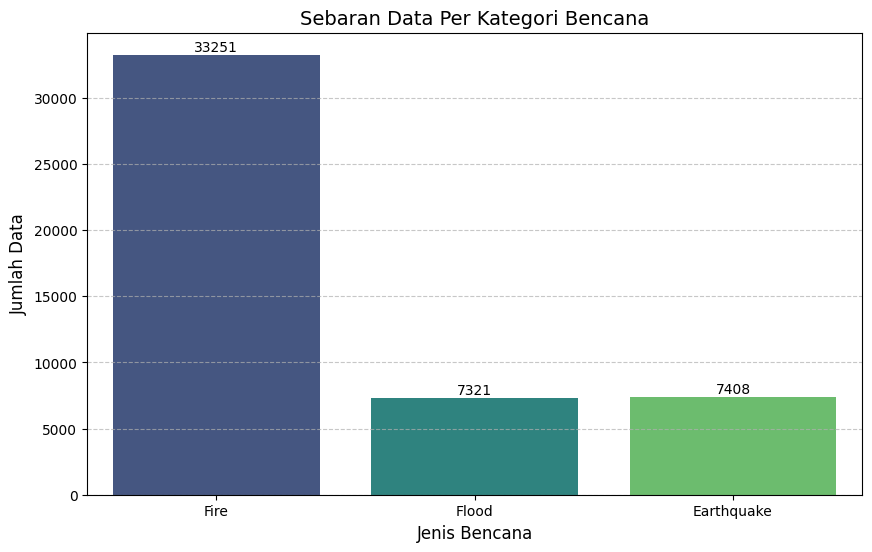

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

data_counts = {
    'Fire': len(df_fire),
    'Flood': len(df_flood),
    'Earthquake': len(df_earthquake)
}

df_counts = pd.DataFrame(list(data_counts.items()), columns=['Disaster Type', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Disaster Type', y='Count', data=df_counts, palette='viridis', hue='Disaster Type', legend=False)

plt.title('Sebaran Data Per Kategori Bencana', fontsize=14)
plt.xlabel('Jenis Bencana', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)

for index, row in df_counts.iterrows():
    plt.text(index, row.Count, str(row.Count), color='black', ha="center", va="bottom")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Data Preparation
Menggabungkan ketiga dataset dan membuat label: 0 (Fire), 1 (Flood), 2 (Earthquake).

In [ ]:
from sklearn.model_selection import train_test_split

# Assign labels
df_fire['label'] = 0
df_flood['label'] = 1
df_earthquake['label'] = 2

# Combine data
df_all = pd.concat([df_fire, df_flood, df_earthquake], ignore_index=True)

# 1. First split: 80% Train, 20% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    df_all['full_text'],
    df_all['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_all['label']
)

# 2. Second split: Split Temp into 50% Val and 50% Test (results in 10% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f'Total samples: {len(df_all)}')
print(f'Train size: {len(X_train)} (80%)')
print(f'Val size: {len(X_val)} (10%)')
print(f'Test size: {len(X_test)} (10%)')

Total samples: 47980
Train size: 38384 (80%)
Val size: 4798 (10%)
Test size: 4798 (10%)


### IndoBERT Modeling
Menggunakan `indobenchmark/indobert-base-p1`.

In [ ]:
import torch

# Check if CUDA (GPU support) is available
if torch.cuda.is_available():
    print("GPU is available!")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    device = torch.device("cuda")
else:
    print("GPU is NOT available. Using CPU instead.")
    device = torch.device("cpu")

print(f"Using device: {device}")

GPU is available!
GPU Name: Tesla T4
Number of GPUs: 1
Using device: cuda


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset

model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Prepare datasets including Validation set
train_ds = Dataset.from_dict({"text": X_train.tolist(), "label": y_train.tolist()})
val_ds = Dataset.from_dict({"text": X_val.tolist(), "label": y_val.tolist()})
test_ds = Dataset.from_dict({"text": X_test.tolist(), "label": y_test.tolist()})

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)
tokenized_test = test_ds.map(tokenize_function, batched=True)

# Initialize model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
model.to(device)

training_args = TrainingArguments(
    output_dir="./indobert_results",
    eval_strategy="steps",
    eval_steps=100,
    logging_steps=100, # Menambahkan logging steps agar train loss tercatat setiap 100 step
    save_strategy="steps",
    save_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    weight_decay=0.01,
    fp16=True if torch.cuda.is_available() else False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Starting IndoBERT retraining with logging_steps=100...")
trainer.train()
trainer.save_model("./IndoBERT")

Map:   0%|          | 0/38384 [00:00<?, ? examples/s]

Map:   0%|          | 0/4798 [00:00<?, ? examples/s]

Map:   0%|          | 0/4798 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

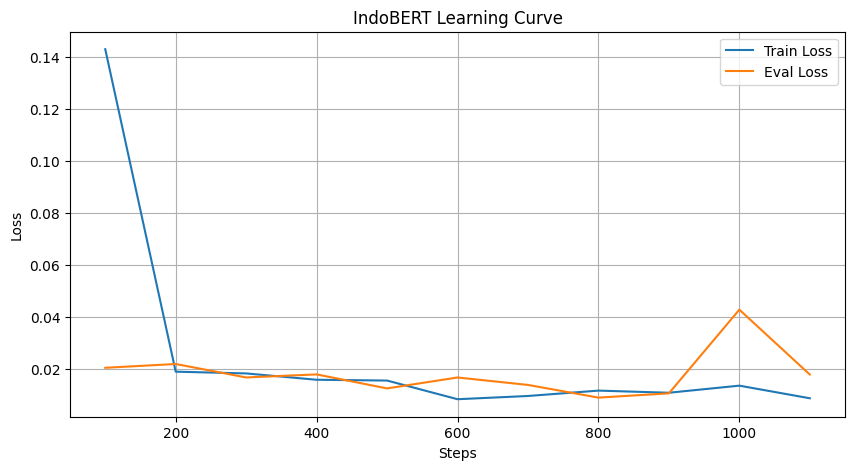

Loading saved model for evaluation...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- Classification Report: IndoBERT ---
              precision    recall  f1-score   support

        Fire       1.00      1.00      1.00      3325
       Flood       1.00      0.99      0.99       732
  Earthquake       0.99      1.00      0.99       741

    accuracy                           1.00      4798
   macro avg       1.00      0.99      1.00      4798
weighted avg       1.00      1.00      1.00      4798



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np
import os
from transformers import AutoModelForSequenceClassification, Trainer

# 1. Learning Curve Analysis
if 'trainer' in globals() and hasattr(trainer, 'state') and trainer.state.log_history:
    history = trainer.state.log_history
    train_loss = [x['loss'] for x in history if 'loss' in x]
    eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
    steps = [x['step'] for x in history if 'loss' in x]
    eval_steps = [x['step'] for x in history if 'eval_loss' in x]

    plt.figure(figsize=(10, 5))
    if train_loss: plt.plot(steps, train_loss, label='Train Loss')
    if eval_loss: plt.plot(eval_steps, eval_loss, label='Eval Loss')
    plt.title('IndoBERT Learning Curve')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Training history not found in current session.")

# 2. Classification Report
if os.path.exists("./indobert_final_model"):
    print("Loading saved model for evaluation...")
    eval_model = AutoModelForSequenceClassification.from_pretrained("./indobert_final_model")
    eval_model.to(device)

    temp_trainer = Trainer(model=eval_model)
    raw_pred, _, _ = temp_trainer.predict(tokenized_test)
    y_pred_bert = np.argmax(raw_pred, axis=1)

    label_names = ['Fire', 'Flood', 'Earthquake']
    print("\n--- Classification Report: IndoBERT ---")
    print(classification_report(y_test, y_pred_bert, target_names=label_names))
else:
    print("Saved model not found. Please ensure cell c8f35b36 finishes training.")

### Training BiLSTM dengan FastText
Menggunakan FastText untuk merepresentasikan kata ke dalam ruang vektor sebelum melatih model BiLSTM (Bidirectional Long Short-Term Memory).

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1. Download FastText Indonesia
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz
!gunzip -f cc.id.300.vec.gz

# 2. Tokenisasi Data
max_words = 20000
max_len = 100
tokenizer_lstm = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_test), maxlen=max_len)

# 3. Load FastText Embedding Matrix (300 Dimensi)
ft_embedding_dim = 300
ft_embeddings_index = {}
with open('cc.id.300.vec', encoding='utf-8') as f:
    next(f) # skip header
    for line in f:
        values = line.rstrip().split(' ')
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        ft_embeddings_index[word] = coefs

word_index = tokenizer_lstm.word_index
ft_embedding_matrix = np.zeros((max_words, ft_embedding_dim))
for word, i in word_index.items():
    if i < max_words:
        embedding_vector = ft_embeddings_index.get(word)
        if embedding_vector is not None:
            ft_embedding_matrix[i] = embedding_vector

print(f"Total {len(ft_embeddings_index)} FastText vectors loaded.")

Total 2000000 FastText vectors loaded.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Update sequences for the 3-way split
X_train_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train), maxlen=max_len)
X_val_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_val), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_test), maxlen=max_len)

# Rebuild model
model_lstm = Sequential([
    Embedding(max_words, ft_embedding_dim, weights=[ft_embedding_matrix], trainable=False),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("Memulai retraining BiLSTM dengan split Train/Val/Test...")
history_lstm = model_lstm.fit(
    X_train_seq, y_train,
    epochs=20,
    validation_data=(X_val_seq, y_val), # Use validation set
    batch_size=64,
    callbacks=[early_stop]
)

model_lstm.save('BiLSTM.h5')
print("\nModel BiLSTM (FastText) berhasil disimpan.")

Memulai retraining BiLSTM dengan split Train/Val/Test...
Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.9480 - loss: 0.1661 - val_accuracy: 0.9900 - val_loss: 0.0435
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9903 - loss: 0.0441 - val_accuracy: 0.9902 - val_loss: 0.0423
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.9936 - loss: 0.0267 - val_accuracy: 0.9921 - val_loss: 0.0331
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9948 - loss: 0.0214 - val_accuracy: 0.9917 - val_loss: 0.0239
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9969 - loss: 0.0144 - val_accuracy: 0.9952 - val_loss: 0.0228
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.9964 - loss: 0.0138 - val_accuracy: 0.9960 - val_loss: 0.0160
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.9964 - loss: 0.0118 - val_accuracy: 0.9948 - val_loss: 0.0156
Epoch 8/20
600/600 ━━━━━━━━━━━━━━


Model BiLSTM (FastText) berhasil disimpan.


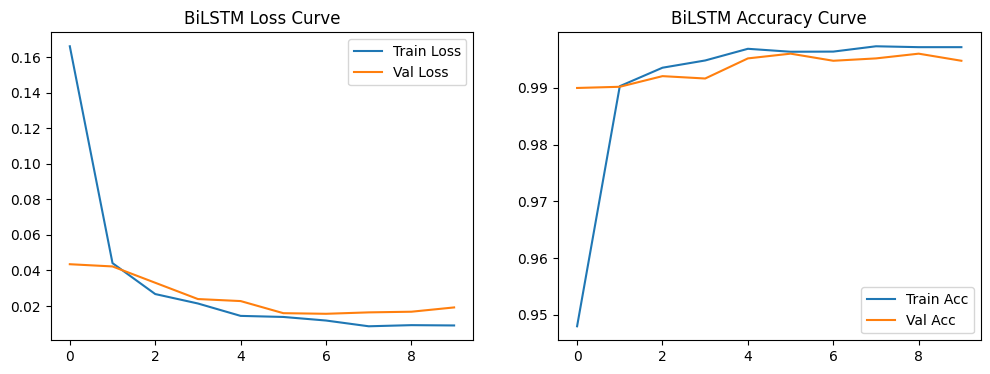

150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step

--- Classification Report: BiLSTM with GloVe ---
              precision    recall  f1-score   support

        Fire       1.00      1.00      1.00      3325
       Flood       1.00      0.98      0.99       732
  Earthquake       0.98      1.00      0.99       741

    accuracy                           1.00      4798
   macro avg       0.99      0.99      0.99      4798
weighted avg       1.00      1.00      1.00      4798



In [ ]:
# 6. Learning Curve Analysis
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('BiLSTM Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Acc')
plt.plot(history_lstm.history['val_accuracy'], label='Val Acc')
plt.title('BiLSTM Accuracy Curve')
plt.legend()
plt.show()

# 7. Classification Report
y_pred_probs = model_lstm.predict(X_test_seq)
y_pred_lstm = np.argmax(y_pred_probs, axis=1)

print("\n--- Classification Report: BiLSTM with GloVe ---")
print(classification_report(y_test, y_pred_lstm, target_names=['Fire', 'Flood', 'Earthquake']))

In [ ]:
import pandas as pd
import numpy as np

# 1. Get IndoBERT Predictions
print("Getting IndoBERT predictions...")
raw_pred_bert, _, _ = trainer.predict(tokenized_test)
y_pred_bert = np.argmax(raw_pred_bert, axis=1)

# 2. Get BiLSTM Predictions
print("Getting BiLSTM predictions...")
y_pred_probs_lstm = model_lstm.predict(X_test_seq, verbose=0)
y_pred_lstm = np.argmax(y_pred_probs_lstm, axis=1)

# 3. Create Comparison DataFrame
label_map = {0: 'Fire', 1: 'Flood', 2: 'Earthquake'}

comparison_df = pd.DataFrame({
    'Full Text': X_test.values,
    'Actual Label': [label_map[y] for y in y_test],
    'IndoBERT Pred': [label_map[y] for y in y_pred_bert],
    'BiLSTM Pred': [label_map[y] for y in y_pred_lstm]
})

# Display first 20 samples for inspection
print("\n--- Sample Results (First 20 Test Data) ---")
display(comparison_df.head(20))

Getting IndoBERT predictions...


Getting BiLSTM predictions...

--- Sample Results (First 20 Test Data) ---


,Full Text,Actual Label,IndoBERT Pred,BiLSTM Pred
0,salurkan bantuan logistik untuk bantu kebutuhan permakanan warga terdampak bencana gempa bumi di kabupaten memberamo tengah papua adapun bantuan yang disalurkan per 10 september 2022 yakni 1080 paket makanan siap saji dan 320 paket makanan anak,Earthquake,Earthquake,Earthquake
1,peringatkan ancaman gempa bumi di banten bmkg: risiko besar di kota cilegon,Earthquake,Earthquake,Earthquake
2,nih masa banjir di shah alam hari itu sekor batang hidung pun tak menampak jaga lalu lintas 3 hari yang critical time itu sekor pun takda yang jaga time itu brader2 fp dengan grab kalau part menyaman dengan paw orang laju jer,Flood,Flood,Flood
3,10 getaran bak gempa bumi terasa di pks dari para kadernya yang hengkang catat saja nama pendiri pks yang sudah lama hengkang dari pks: (alm) yusuf supendi,Earthquake,Earthquake,Earthquake
4,guys aku tau akun ku kecil tapi apa salahnya mencoba :) banjir diberbagai wilayah di kalimantan tengah yang belum banyak orang tau,Flood,Flood,Flood
5,hari ini: bupati datangi korban kebakaran di maria wawo,Fire,Fire,Fire
6,senin 30 agustus 2021 pukul 1930 wib unit garuda 112 yang terdiri dari petugas operator 112 petugas bpbd kudus relawan frpb rapi trak human initiative fkppi relawan iea dan warga sekitar melakukan giat pemadaman kebakaran lahan tebu di dk ngaringan,Fire,Fire,Fire
7,mau tidur lihat drama cukuran mata melek lagi n senyum2 sendiri hadooohhh semakin lama mereka keluar semakin ramai scene2 gemas bahagia sedih banjir di medsos,Flood,Flood,Flood
8,isu mengenai kebakaran lahan gambut di indonesia telah menjadi isu penting selama dua dekade terakhir mengingat besarnya dampak dan kerugian yang ditimbulkan dari bencana kebakaran lahan gambut pemerintah indonesia pun berkomitmen untuk mencegah terjadinya kebakaran lahan,Fire,Fire,Fire
9,kebakaran di simeulue aceh 15 unit ruko ludes terbakar - infonanggroe,Fire,Fire,Fire
